# Simulation Example: CLUES-ABM under Production Capacity Disruption

This guide demonstrates how to use the `clues_abm` library to simulate and evaluate the dynamic impacts of a production capacity disruption on inter-city economic networks and supply chains.

---

### 1. Module Imports and Engine Instantiation
We import standard data tensor libraries and the vectorized multi-agent class from our core package.

In [10]:
import numpy as np
import pandas as pd
from scipy.io import loadmat
import matplotlib.pyplot as plt
from clues_abm.WorldOfMatrix_GPU import WorldOfMatrixGPU

# Instantiate the high-performance model engine
model = WorldOfMatrixGPU()
print("CLUES-ABM Matrix Engine successfully instantiated.")

CLUES-ABM Matrix Engine successfully instantiated.


### 2. Temporal Horizon and Discretization Calibration

Before ingesting empirical regional matrices, we parameterize the structural temporal boundaries of the evolutionary ecosystem. 

* **Simulation Horizon (`day_total = 365`)**: Represents a full annual calendar cycle (365 days). This alignment is critical for tracking macro-economic indicators, seasonal bio-geochemical cycles, and policy shock propagation windows that typically operate on sub-national accounting timelines.
* **Temporal Discretization Step (`delta_t = 1/365`)**: Calibrates each fundamental loop iteration to represent exactly **one single day**. Operating on a daily time-step balances the computational tractability of massive multi-agent parallel tensors with the high-resolution capture of abrupt supply chain dislocations and transportation chain delays.

> ⏳ **Computational Benchmarking & Quick Evaluation Switch**
> * **Expected Runtime**: Executing the full 365-day vectorized socio-ecological simulation takes approximately **1 to 3 minutes** (depending on your CPU topology and GPU/CUDA acceleration alignment). 
> * **Quick Evaluation Switch**: If you prefer a rapid functional checkout without waiting, you can manually decrease the temporal boundary variable `day_total` in the code block below (e.g., set `day_total = 50`). This will allow the model to fully bootstrap and execute a shortened lifecycle in just a few seconds.

In [11]:
# Parameterize Temporal Boundaries
# [USER OPTION] Decrease day_total (e.g., 50) for a rapid functional checkout
day_total = 365 

# Define the temporal discretization step (1 day represented as 1/365 of a year)
delta_t = 1 / 365

print(f"============================================================")
print(f"🚀 CLUES-ABM Execution Pipeline Initiated.")
print(f"⏱️ Target Temporal Horizon: {day_total} Days | delta_t = {delta_t:.6f}")
print(f"💡 Note: Full 365 days take ~1-3 mins. If too slow, reduce 'day_total'.")
print(f"============================================================")

🚀 CLUES-ABM Execution Pipeline Initiated.
⏱️ Target Temporal Horizon: 365 Days | delta_t = 0.002740
💡 Note: Full 365 days take ~1-3 mins. If too slow, reduce 'day_total'.


### 3. Multi-Regional Input-Output (MRIO) Bootstrapping & Agent Initialization
Here, we ingest the empirical inter-regional trade data (`CityLevelMRIO2017-python.mat`) to establish the baseline economic network topology. The tensor structures partition production agents, consumption agents, and transportation agents across highly heterogeneous geographic regions.

In [21]:
print("⏳ Phase 1/3: Ingesting empirical MRIO data structures...")
# Load the empirical data structure
mat = loadmat("data/ProvinceLevelMRIO2017.mat")

# Default targeted inventory periods
# Note: This is (1 + the number of periods the remaining inputs would last after the current production ends). Therefore, it should be >= 1.
ndays_target_default = 3

# Bind structural MRIO network configurations to the agent layers
MRIOdata = {
    "MRIO_Z": mat["Z_MRIO2017"],
    "MRIO_C": mat["C_MRIO2017"],
    "MRIO_E": mat["E_MRIO2017"],
    "MRIO_IC": mat["IC_MRIO2017"].flatten().reshape(1, -1),
    "MRIO_IP": mat["IP_MRIO2017"].flatten().reshape(1, -1),
    "MRIO_R": int(mat["R_MRIO2017"].item()),
    "MRIO_S": int(mat["S_MRIO2017"].item()),
    "MRIO_VA": mat["VA_MRIO2017"].flatten().reshape(1, -1)
}

print("⏳ Phase 2/3: Loading environmental tensors and aggregation mappings from Excel...")
# Load water intensity and water resource data.
WaterConstraints_Ratio = pd.read_excel("data/WaterVariables.xlsx", sheet_name="WaterConstraints_Ratio", header=None).values
WaterIntensity = pd.read_excel("data/WaterVariables.xlsx", sheet_name="WaterIntensity", header=None).values.reshape(-1)

# Load the conversion matrix from sectors to aggregate sectors.
#  The rows represent products in MRIO table, and the columns are aggregate products 
#  which are used as inputs to the Leontief production function.
#  In the matrix, 1 means the row product belongs to the column aggregate proudct, and 0 otherwise.
#  If it is an identity matrix, the original product classification 
#  will be the same as the aggregate product classification.
#  Experiments show that when inventories are small, aggregation will reduce losses;
#  otherwise using aggregation will slightly increase losses.
S2Sa = pd.read_excel('data/S2Sa.xlsx', sheet_name='S2Sa_Identical', header=None)

print("⏳ Phase 3/3: Mapping structural IO boundaries and bootstrapping ABM agent layers (this may take a moment)...")
# ==== Basic Input-Output variables ====
model.MRIO_R = int(MRIOdata["MRIO_R"]) # Number of regions (cities).
model.MRIO_S = int(MRIOdata["MRIO_S"]) # Number of sectors in each region.
model.MRIO_Z = MRIOdata["MRIO_Z"] # Intermediate flows (in a year) from each city-region to each city-region.
model.MRIO_C = MRIOdata["MRIO_C"] # Consumption. Each column is the consumption of a city from all city-sectors.
model.MRIO_VA = MRIOdata["MRIO_VA"] # Value added of each city-sector.

# Define open-economy variables.
model.OpenEcon = True # China is an open economy.
model.MRIO_E = MRIOdata["MRIO_E"] # Exports.
model.MRIO_IP = MRIOdata["MRIO_IP"] # Exports.
model.MRIO_IC = MRIOdata["MRIO_IC"] # Exports.


# Set MRIO_Dist: default 1
TransportationDays = pd.read_excel("data/TransportationDays_ProvincesInChina.xlsx",sheet_name="TransportationDays", header=None).values
model.MRIO_Dist = TransportationDays - 1

# Length of each time step, as a fraction of input flows.
model.delta_t = delta_t

# Default targeted inventory days.
model.ndays_Target_Default = ndays_target_default

# Water intensity: placeholder
model.AgentsP_ResourceIntensity = np.ones((model.MRIO_R * model.MRIO_S, 1)).reshape(-1)

# A conversion matrix, each row is a product and each column is an aggregate product. 
# The value is 1 if the column is aggregate product for the row product, otherwise is 0.
model.S2Sa = S2Sa.values # Use the imported conversion matrix.

# Initialize
model.initialize_variables()
model.initialize_production_agents()
model.initialize_consumption_agents()
model.initialize_transportation_agents()

print(f"Socio-ecological network initialized: {model.MRIO_R} Regions, {model.MRIO_S} Sectors aligned.")

⏳ Phase 1/3: Ingesting empirical MRIO data structures...
⏳ Phase 2/3: Loading environmental tensors and aggregation mappings from Excel...
⏳ Phase 3/3: Mapping structural IO boundaries and bootstrapping ABM agent layers (this may take a moment)...
Socio-ecological network initialized: 31 Regions, 42 Sectors aligned.


### 4. Exogenous Regulatory Shocks and Vectorized Simulation Loop
We parameterized three distinct temporal shock windows representing production-capacity reduction constraints (e.g., severe environmental regulation or resource scarcity events). The block propagates supply chain delays across augmented transportation layers over a full 365-day annual horizon.

In [22]:
# Initialize matrix recorders for temporal tracking
S0_Evolution_ValueAdded_ProductionAgents = np.zeros((model.N_P, day_total))
RegionSectors2Regions = np.kron(np.eye(model.MRIO_R), np.ones((model.MRIO_S, 1)))
SS_AgentsP_VA = model.AgentsP_VA
SS_Region_VA = RegionSectors2Regions.T @ SS_AgentsP_VA
S0_ProductInNetwork_Region = np.zeros((model.MRIO_R, model.MRIO_R, day_total))
S0_ProductInNetwork_Region_Change = np.zeros_like(S0_ProductInNetwork_Region)
SS_ProductInNetwork_Region = RegionSectors2Regions.T @ model.AgentsP_ProductInP @ RegionSectors2Regions
S0_Evolution_Scarcity_RegionsProducts = np.zeros((model.MRIO_R, model.Sa, day_total))

print("Starting 365-day vectorized state transition simulation...")

# Core Evolutionary Simulation Loop
for day in range(1, day_total + 1):
    # Print progress milestone logs periodically to avoid standard terminal clutter
    if day % 50 == 0 or day == 1:
        print(f" >>> Simulating Temporal Boundary: Day {day}/{day_total}")
    
    # To simulate the impact of losses in production capacity:
    # We can revise the property obj.AgentsP_Theta of the WorldOfMatrix_GPU object:
    # obj.N_P * 1: Reduction in production capcity relative to pre-event level, in [0,1].
    if 1 <= day <= 10:  # For example, production capacity loss in the fist period:
        model.AgentsP_Theta[0] = 0.4  #The production capacity of the first sector in the first region decreased by 40%

    # --- Augmented Transportation Layers Control (P2P and P2C) ---
    # Tranportation lines:
    # Load, move, and unload goods in the transportation chains.
    # Move one step forward (creating augumented transportation lines), for P2P.
    model.AgentsT_P2P = np.hstack([np.zeros((model.nl_NetPP, 1)), model.AgentsT_P2P])
    # Calculate products loaded to each transportation lines.
    flat_P2P = model.AgentsT_P2P.ravel(order='F').copy()
    flat_P2P[model.AgentsT_P2P_StartLinInd] = model.AgentsP_ProductOutP.ravel(order='F')[model.k_NetPP]
    model.AgentsT_P2P = flat_P2P.reshape(model.AgentsT_P2P.shape, order='F')
    
    # Move one step forward (creating augumented transportation lines), for P2C.
    model.AgentsT_P2C = np.hstack([np.zeros((model.nl_NetPC, 1)), model.AgentsT_P2C])
    # Calculate products loaded to each transportation lines.
    flat_P2C = model.AgentsT_P2C.ravel(order='F').copy()
    flat_P2C[model.AgentsT_P2C_StartLinInd] = model.AgentsP_ProductOutC.ravel(order='F')[model.k_NetPC]  
    model.AgentsT_P2C = flat_P2C.reshape(model.AgentsT_P2C.shape, order='F')
    
    # Transportation line obstruction (optional).
    # HERE WE DO NOTHING SINCE THERE IS NO TRANSPORTATION LINE OBSTRUCTION.

    # Calculate products unloaded to each production agent from transportation lines.
    temp2 = model.AgentsP_ProductInP.T.copy()
    flat_temp = temp2.ravel(order='F').copy()
    flat_temp[model.k_NetPP] = model.AgentsT_P2P[:, -1]
    temp2 = flat_temp.reshape(temp2.shape, order='F')
    model.AgentsP_ProductInP = temp2.T.copy()
    model.AgentsT_P2P = model.AgentsT_P2P[:, :-1]
    
    # Calculate products unloaded to each consumption agent from transportation lines.
    temp2 = model.AgentsC_ProductInP.T.copy()
    flat_temp = temp2.ravel(order='F').copy()
    flat_temp[model.k_NetPC] =  model.AgentsT_P2C[:, -1]
    temp2 = flat_temp.reshape(temp2.shape, order='F')
    model.AgentsC_ProductInP = temp2.T.copy()
    model.AgentsT_P2C = model.AgentsT_P2C[:, :-1]
    del temp2, flat_temp

    # --- Multi-Agent Behavioral Functions ---
    model.agents_communicate()
    model.update_inventories()
    model.update_export_orders()
    model.update_shares()
    model.production_agents_produce()
    model.production_agents_prepare_product_out()
    model.production_agents_prepare_order_out()
    model.production_agents_adapt_to_shocks()
    model.production_agents_adapt_to_shortages()
    model.production_agents_remember()
    model.consumption_agents_consume()
    model.consumption_agents_prepare_order_out()
    model.consumption_agents_remember()

    # --- Capture End-of-Day System States ---
    S0_Evolution_ValueAdded_ProductionAgents[:, day-1] = model.AgentsP_VA.flatten()
    flow = RegionSectors2Regions.T @ model.AgentsP_ProductInP @ RegionSectors2Regions
    S0_ProductInNetwork_Region[:, :, day-1] = flow
    S0_ProductInNetwork_Region_Change[:, :, day-1] = flow - SS_ProductInNetwork_Region
    S0_Evolution_Scarcity_RegionsProducts[:, :, day-1] = model.Scarcity_RegionsProducts

print("Simulation loop execution finalized.")

Starting 365-day vectorized state transition simulation...
 >>> Simulating Temporal Boundary: Day 1/365


D:\project\my_jupyter_notebooks\CLUES_AI_Application\clues_abm\WorldOfMatrix_GPU.py:549: RuntimeWarning: divide by zero encountered in divide
  self.AgentsP_Xs = (self.AgentsP_I + (self.AgentsP_a == 0)) / self.AgentsP_a


 >>> Simulating Temporal Boundary: Day 50/365
 >>> Simulating Temporal Boundary: Day 100/365
 >>> Simulating Temporal Boundary: Day 150/365
 >>> Simulating Temporal Boundary: Day 200/365
 >>> Simulating Temporal Boundary: Day 250/365
 >>> Simulating Temporal Boundary: Day 300/365
 >>> Simulating Temporal Boundary: Day 350/365
Simulation loop execution finalized.


### 5. Post-Processing & Visual Analytics
We synthesize the macro-level economic cascading indices by calculating the temporal deviations in regional Value-Added (VA). The pre-rendered line graph mirrors the economic trajectory published in our accompanying manuscript.

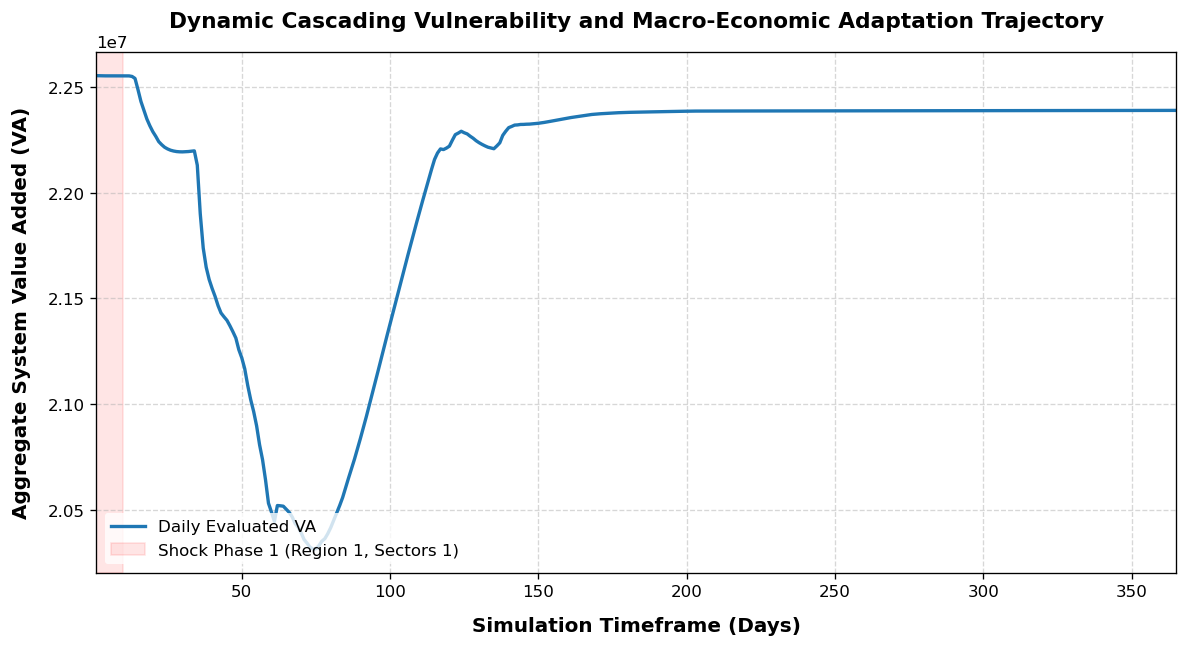

In [24]:
# Compute aggregated macro-level evolution metrics
S0_Evolution_ValueAdded_Region = RegionSectors2Regions.T @ S0_Evolution_ValueAdded_ProductionAgents
daily_total_va = np.sum(S0_Evolution_ValueAdded_ProductionAgents, axis=0)

# ======================= Matplotlib Academic Standard Charting =======================
plt.figure(figsize=(10, 5.5), dpi=120)
plt.plot(range(1, day_total + 1), daily_total_va, label='Daily Evaluated VA', color='#1f77b4', linewidth=2)

# Structural Annotations for Policy Shock Windows
plt.axvspan(1, 10, color='red', alpha=0.1, label='Shock Phase 1 (Region 1, Sectors 1)')

# Formatting Aesthetics
plt.xlabel('Simulation Timeframe (Days)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Aggregate System Value Added (VA)', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Dynamic Cascading Vulnerability and Macro-Economic Adaptation Trajectory', fontsize=13, fontweight='bold', pad=15)
plt.xlim(1, day_total)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower left', frameon=True, facecolor='white', edgecolor='none', fontsize=10)
plt.tight_layout()

# Render inline chart directly inside the notebook environment
plt.show()